# End-to-End Pipeline for Crop Pest and Disease Detection

## Introduction

This notebook builds an end-to-end pipeline for classifying crop diseases from the provided dataset. The pipeline will cover data loading, preprocessing, model building, training, and evaluation.

### 1. Import Libraries

In [ ]:
%pip install -Uq numpy scipy tensorflow matplotlib scikit-learn seaborn


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

### Generate Data

Found 25220 images belonging to 4 classes.


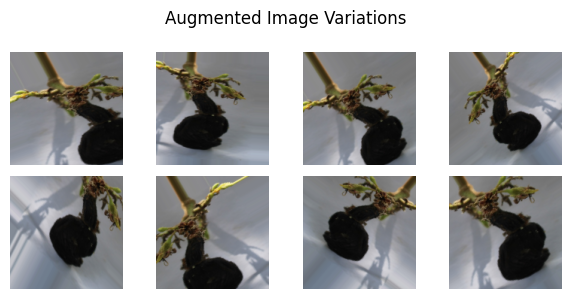

In [ ]:
raw_base_dir = 'crop_dataset/Dataset for Crop Pest and Disease Detection/Raw Data/CCMT Dataset'

augment_datagen = ImageDataGenerator(
        rescale = 1./255,
        rotation_range=40,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(rescale=1./255)

train_augment_datagen = augment_datagen.flow_from_directory(
    raw_base_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical'
)

img_path= os.path.join(raw_base_dir ,'Cashew/anthracnose/anthracnose2_.jpg')

img = tf.keras.utils.load_img(img_path, target_size=(150,150))
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

aug_iterator = augment_datagen.flow(img_array, batch_size=10)
plt.figure(figsize=(6,3))

for i in range(8):

    ax = plt.subplot(2, 4, i+1  )
    image = next(aug_iterator)
    plt.imshow(image[0])
    plt.axis('off')

plt.suptitle("Augmented Image Variations")
plt.tight_layout()
plt.show()

In [ ]:
exclusion_list = ['.DS_Store']
is_first_run = False

for dirpath, dirnames, filenames in os.walk(raw_base_dir)  :
    for cur_file in filenames:
        #print("cur_file : " , cur_file)
        if cur_file in exclusion_list:
            break

        is_first_run = True
        try:
            cur_img_loc = os.path.join(dirpath, cur_file)
            img = tf.keras.utils.load_img(cur_img_loc, target_size=(150,150))
            img_array = tf.keras.utils.img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0)
            target_dir1 =  dirpath[dirpath.rfind("/")+1:]
            intermediate_dir = dirpath[:dirpath.rfind("/")]
            target_dir2 = intermediate_dir[intermediate_dir.rfind("/")+1:]
            new_target_dir = "_".join([target_dir2, target_dir1])
            train_target_loc = os.path.join('dataset/train', new_target_dir)
            test_target_loc = os.path.join('dataset/test', new_target_dir)
            os.makedirs(train_target_loc, exist_ok=True)
            os.makedirs(test_target_loc, exist_ok=True)

            aug_iterator = augment_datagen.flow(img_array, batch_size=10)

            for i in range(7):
                image = next(aug_iterator)
                target_file_name = cur_file[:cur_file.rfind(".")]  + str(i) + ".jpg"
                if ( i < 5) :
                    target_file_name = os.path.join(train_target_loc,target_file_name )
                else:
                    target_file_name = os.path.join(test_target_loc,target_file_name )

                tf.keras.utils.save_img(target_file_name, image[0])
        except OSError as ex:
            print( f"Error in lading image {cur_img_loc}  : {ex}")



Error in lading image crop_dataset/Dataset for Crop Pest and Disease Detection/Raw Data/CCMT Dataset/Tomato/healthy/healthy76_.jpg  : broken data stream when reading image file
Error in lading image crop_dataset/Dataset for Crop Pest and Disease Detection/Raw Data/CCMT Dataset/Tomato/healthy/healthy77_.jpg  : cannot identify image file <_io.BytesIO object at 0x150d66ed0>
Error in lading image crop_dataset/Dataset for Crop Pest and Disease Detection/Raw Data/CCMT Dataset/Tomato/healthy/healthy442_.jpg  : broken data stream when reading image file
Error in lading image crop_dataset/Dataset for Crop Pest and Disease Detection/Raw Data/CCMT Dataset/Tomato/healthy/healthy443_.jpg  : Truncated File Read
Error in lading image crop_dataset/Dataset for Crop Pest and Disease Detection/Raw Data/CCMT Dataset/Tomato/leaf blight/leaf blight471_.jpg  : cannot identify image file <_io.BytesIO object at 0x150a49e40>
Error in lading image crop_dataset/Dataset for Crop Pest and Disease Detection/Raw Data

### 2. Load Data

In [ ]:
#base_dir = 'crop_dataset/Dataset for Crop Pest and Disease Detection/CCMT Dataset-Augmented'
base_dir= 'dataset'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

The dataset is divided into four main crop types: Cashew, Cassava, Maize, and Tomato. Each of these is further divided into training and testing sets. For this initial pipeline, we will focus on the Cashew dataset.

In [ ]:
"""
import shutil

target_dir = 'data_set'
plant_types = [cur_dir for cur_dir in os.listdir(base_dir) if not cur_dir.startswith('.') ]
exclusion_list = ['.', 'bacterial blight3241','.DS_Store']
#print(plant_types)

def copy_image (sub_folder):
    for cur_plant in plant_types:
        sub_base_dir = os.path.join(base_dir, cur_plant, sub_folder)
        all_species_per_plant = [cur_dir for cur_dir in os.listdir(sub_base_dir) if cur_dir not in exclusion_list ]
        print(all_species_per_plant)

        for cur_species in all_species_per_plant:
            tar_species_folder =  cur_plant + cur_species
            #print(cur_species)

            cur_plant_ds_path = os.path.join(base_dir,  cur_plant, sub_folder, cur_species)
            tar_plant_ds_path = os.path.join(target_dir, sub_folder, tar_species_folder)
            #print(cur_plant_ds_path,tar_plant_ds_path )
            shutil.copytree(cur_plant_ds_path,tar_plant_ds_path, dirs_exist_ok=True  )

        #cur_plant_test_ds_path = os.path.join(base_dir,  cur_plant, 'test_set', cur_species)
        #tar_plant_test_ds_path = os.path.join(target_dir, 'test_set', tar_species_folder)
        #shutil.copytree(cur_plant_test_ds_path,tar_plant_test_ds_path, dirs_exist_ok=True  )

"""

In [ ]:
#copy_image ('train_set')


['mosaic', 'healthy', 'green mite', 'bacterial blight', 'brown spot']
['healthy', 'leaf blight', 'verticulium wilt', 'leaf curl', 'septoria leaf spot']
['anthracnose3102', 'red rust4751', 'leaf miner3466', 'healthy5877', 'gumosis1714']
['leaf beetle', 'healthy', 'leaf blight', 'grasshoper', 'fall armyworm', 'streak virus', 'leaf spot']


In [ ]:
#copy_image ('test_set')

['mosaic', 'healthy', 'green mite', 'bacterial blight', 'brown spot']
['healthy', 'leaf blight', 'verticulium wilt', 'leaf curl', 'septoria leaf spot']
['red rust', 'gumosis', 'anthracnose', 'healthy', 'leaf miner']
['leaf beetle', 'healthy', 'leaf blight', 'grasshoper', 'fall armyworm', 'streak virus', 'leaf spot']


In [ ]:
#target_dir =
#train_dir = os.path.join(target_dir, 'train_set')
#test_dir = os.path.join(target_dir, 'test_set')

In [ ]:
def get_predicting_class(folder):
    plant_classes = [cur_dir for cur_dir in os.listdir(folder) if not cur_dir.startswith('.')]
    print( f"number of plant classes : {len(plant_classes)}")
    print(plant_classes)
    return len(plant_classes)

num_pred_classes = get_predicting_class(train_dir)
get_predicting_class(test_dir)


number of plant classes : 22
['Tomato_verticulium wilt', 'Cashew_leaf miner', 'Cassava_mosaic', 'Tomato_healthy', 'Tomato_septoria leaf spot', 'Cassava_brown spot', 'Cashew_red rust', 'Maize_fall armyworm', 'Maize_grasshoper', 'Maize_leaf blight', 'Tomato_leaf blight', 'Tomato_leaf curl', 'Maize_healthy', 'Cassava_healthy', 'Cassava_bacterial blight', 'Cassava_green mite', 'Maize_leaf beetle', 'Cashew_gumosis', 'Maize_streak virus', 'Maize_leaf spot', 'Cashew_anthracnose', 'Cashew_healthy']
number of plant classes : 22
['Tomato_verticulium wilt', 'Cashew_leaf miner', 'Cassava_mosaic', 'Tomato_healthy', 'Tomato_septoria leaf spot', 'Cassava_brown spot', 'Cashew_red rust', 'Maize_fall armyworm', 'Maize_grasshoper', 'Maize_leaf blight', 'Tomato_leaf blight', 'Tomato_leaf curl', 'Maize_healthy', 'Cassava_healthy', 'Cassava_bacterial blight', 'Cassava_green mite', 'Maize_leaf beetle', 'Cashew_gumosis', 'Maize_streak virus', 'Maize_leaf spot', 'Cashew_anthracnose', 'Cashew_healthy']


22

In [ ]:
IMG_WIDTH = 150
IMG_HEIGHT = 150
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

validation_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 125630 images belonging to 22 classes.
Found 50252 images belonging to 22 classes.


### 3. Exploratory Data Analysis (EDA)

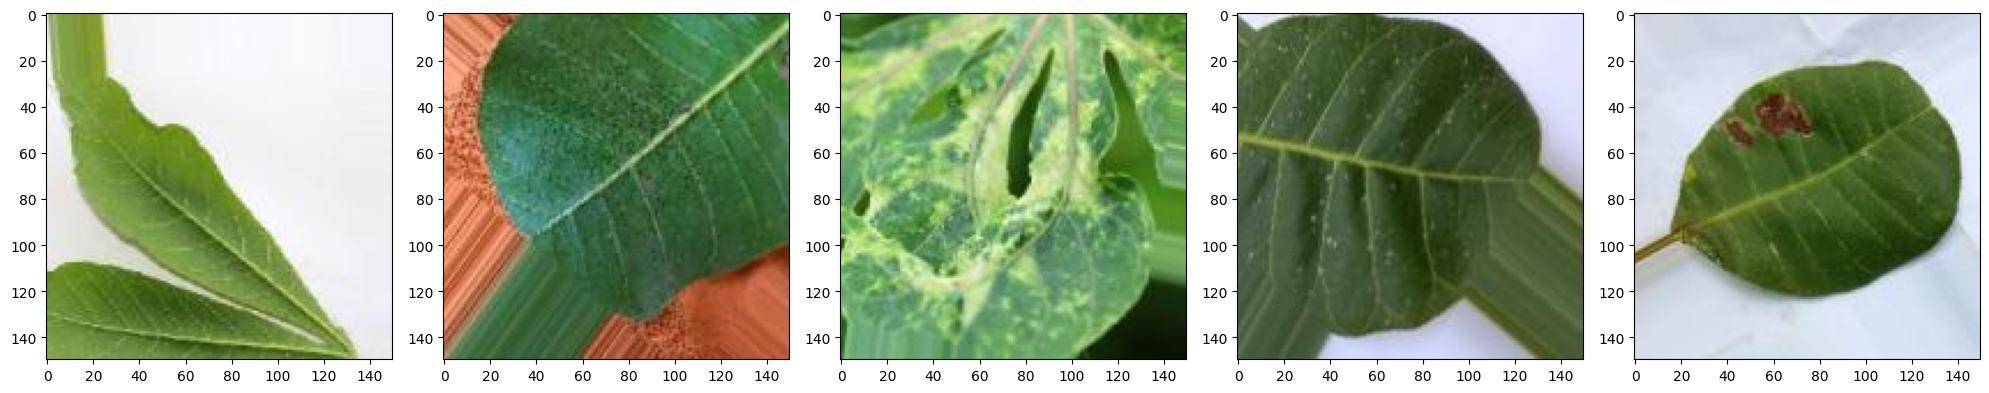

In [ ]:
def plot_images(images_arr):
    fig, axes = plt.subplots(1, 5, figsize=(20,20))
    axes = axes.flatten()
    for img, ax in zip( images_arr, axes):
        ax.imshow(img)
    plt.tight_layout()
    plt.show()

images, _ = next(train_generator)
plot_images(images[:5])

### 4. Model Building

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_WIDTH, IMG_HEIGHT, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(num_pred_classes, activation='softmax') # 5 classes for Cashew
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/Users/sdaskarmakar/Santa/USD/AAI-521-IN4/Project/myenv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 22)             │        11,286 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,463,894 (13.21 MB)

 Trainable params: 3,463,894 (13.21 MB)

 Non-trainable params: 0 (0.00 B)

### 5. Model Training

In [ ]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=10,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE
)

Epoch 1/10
3925/3925 ━━━━━━━━━━━━━━━━━━━━ 1703s 434ms/step - accuracy: 0.5153 - loss: 1.4972 - val_accuracy: 0.6498 - val_loss: 1.0333
Epoch 2/10
   1/3925 ━━━━━━━━━━━━━━━━━━━━ 5:45 88ms/step - accuracy: 0.5938 - loss: 1.2388

/Users/sdaskarmakar/Santa/USD/AAI-521-IN4/Project/myenv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


3925/3925 ━━━━━━━━━━━━━━━━━━━━ 41s 11ms/step - accuracy: 0.5938 - loss: 1.2388 - val_accuracy: 0.6500 - val_loss: 1.0300
Epoch 3/10
3925/3925 ━━━━━━━━━━━━━━━━━━━━ 771s 196ms/step - accuracy: 0.6993 - loss: 0.8798 - val_accuracy: 0.7094 - val_loss: 0.8432
Epoch 4/10
3925/3925 ━━━━━━━━━━━━━━━━━━━━ 46s 12ms/step - accuracy: 0.8438 - loss: 0.4970 - val_accuracy: 0.7126 - val_loss: 0.8337
Epoch 5/10
3925/3925 ━━━━━━━━━━━━━━━━━━━━ 435s 111ms/step - accuracy: 0.7652 - loss: 0.6706 - val_accuracy: 0.7501 - val_loss: 0.7281
Epoch 6/10
3925/3925 ━━━━━━━━━━━━━━━━━━━━ 47s 12ms/step - accuracy: 0.7812 - loss: 0.7026 - val_accuracy: 0.7511 - val_loss: 0.7262
Epoch 7/10
3925/3925 ━━━━━━━━━━━━━━━━━━━━ 473s 120ms/step - accuracy: 0.8107 - loss: 0.5331 - val_accuracy: 0.7411 - val_loss: 0.7789
Epoch 8/10
3925/3925 ━━━━━━━━━━━━━━━━━━━━ 47s 12ms/step - accuracy: 0.7188 - loss: 0.7092 - val_accuracy: 0.7438 - val_loss: 0.7724
Epoch 9/10
3925/3925 ━━━━━━━━━━━━━━━━━━━━ 444s 113ms/step - accuracy: 0.8499 - lo

### 6. Model Evaluation

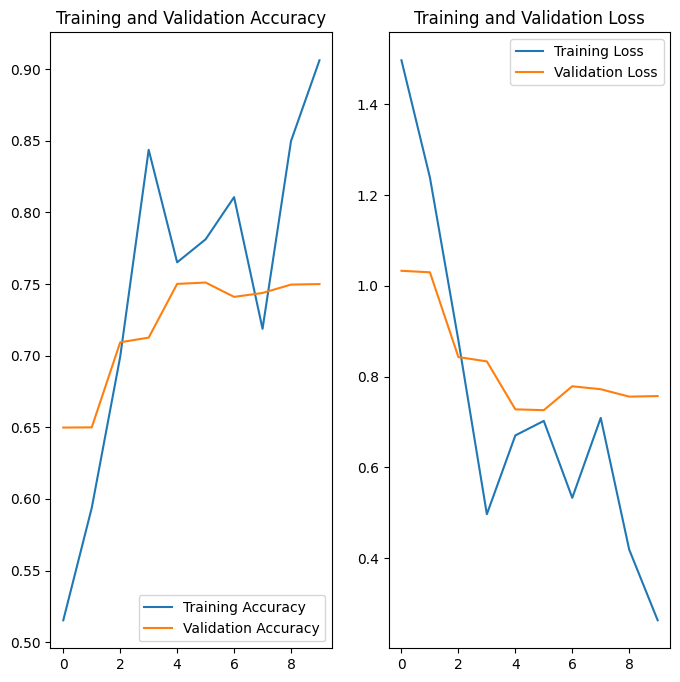

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(10)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

### 7. Conclusion

This notebook provided a complete end-to-end pipeline for an image classification task. We loaded and preprocessed the data, built a convolutional neural network, trained it, and evaluated its performance. The same pipeline can be extended to the other crop types in the dataset.

### 8. Prediction

In [ ]:
test_image_path = 'crop_dataset/Dataset for Crop Pest and Disease Detection/CCMT Dataset-Augmented/Cassava/test_set/'
images_per_directories = dict()
count =0

for dirpath, dirnames, filenames in os.walk(test_image_path):
    if(len(filenames) >5):
        folder_name = dirpath[dirpath.rfind("/") +1:]
        selected_images = random.sample(filenames ,5)
        images_per_directories[folder_name] = selected_images

In [ ]:
from tensorflow.keras.preprocessing import image

def predict_image(test_image_path) :
    # Load and preprocess the image
    img = image.load_img(test_image_path, target_size=(IMG_WIDTH, IMG_HEIGHT))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0

    # Make a prediction
    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction, axis=1)

    # Get the class labels
    class_labels = list(train_generator.class_indices.keys())
    predicted_label = class_labels[predicted_class[0]]
    plt.figure(figsize=(2,2))
    # Display the image and prediction
    plt.imshow(img)
    plt.title(f'Predicted: {predicted_label}')
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


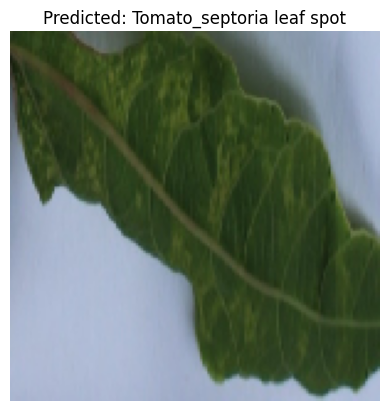

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


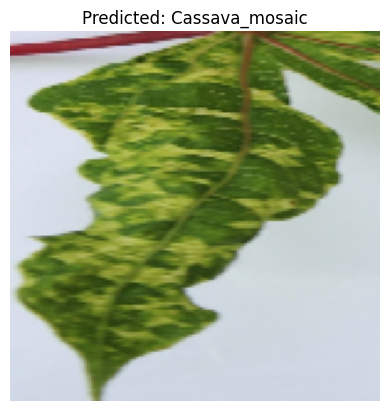

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


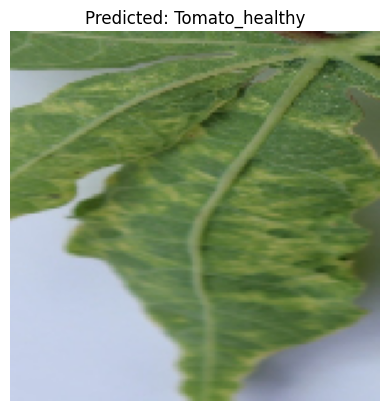

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


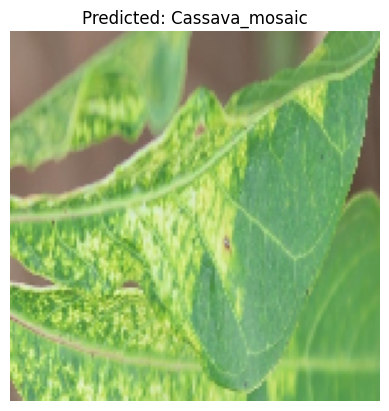

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


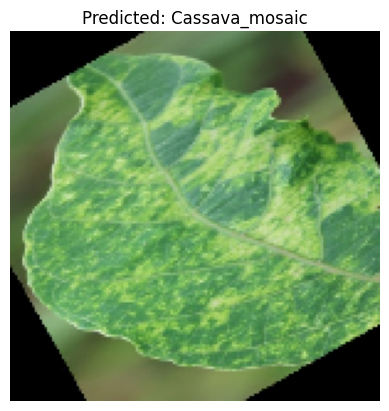

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


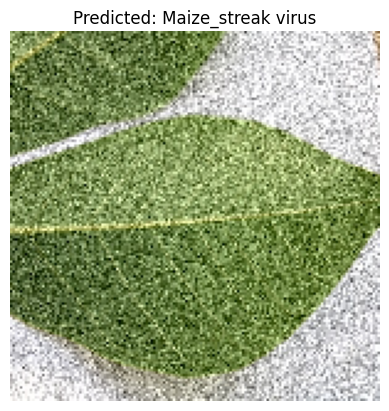

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


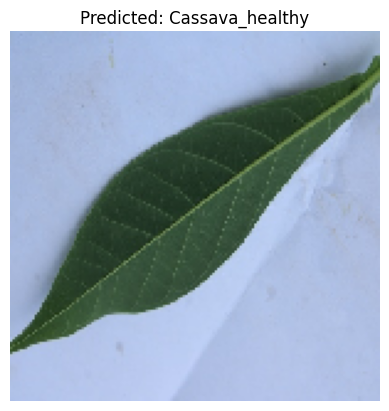

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


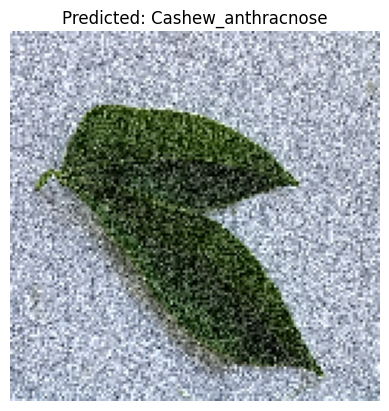

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


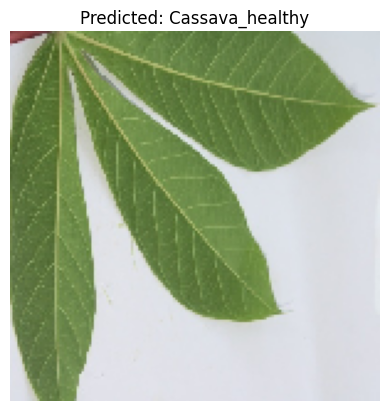

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


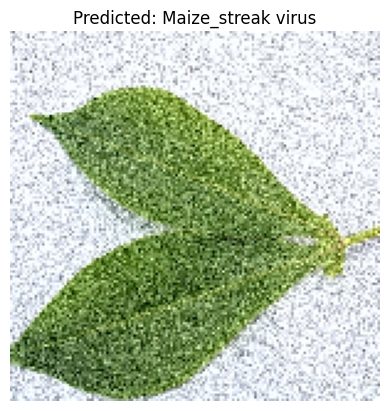

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


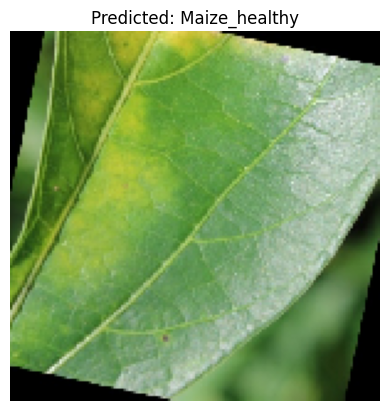

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


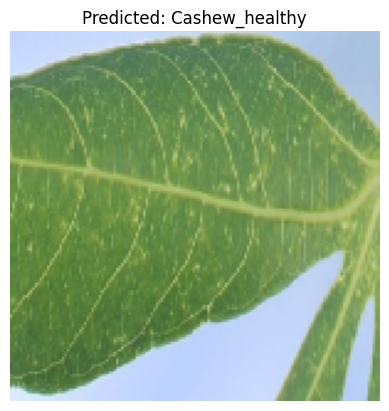

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


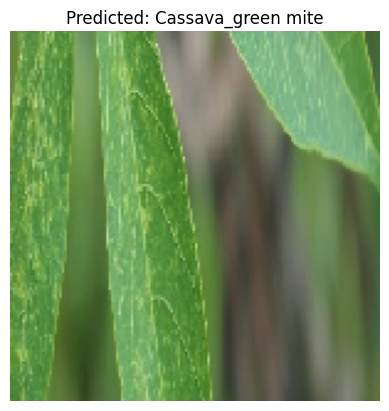

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


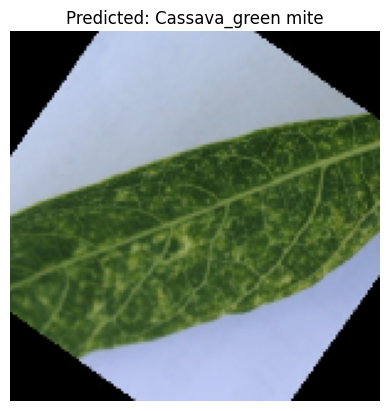

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


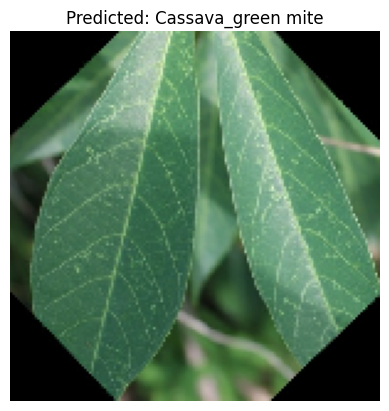

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


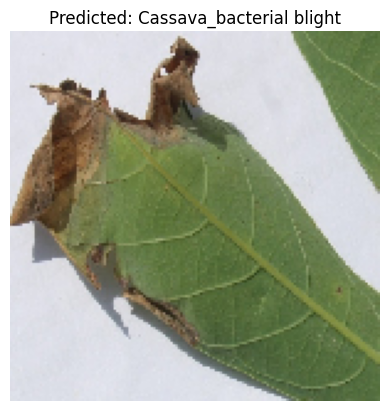

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


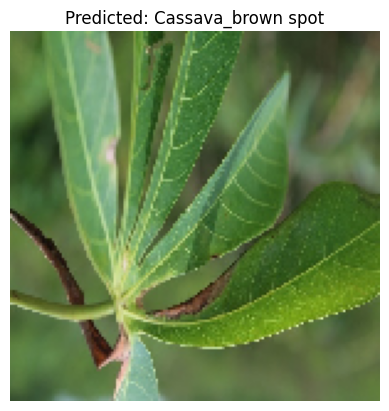

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


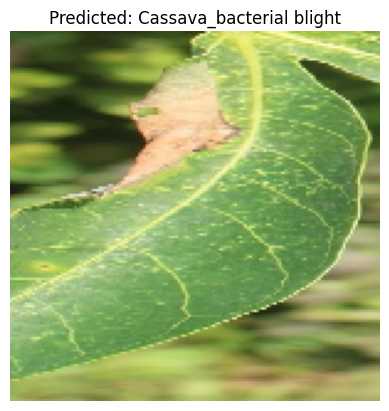

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


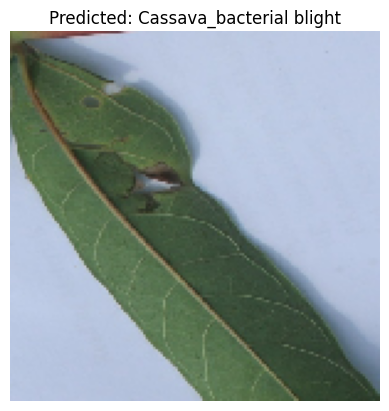

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


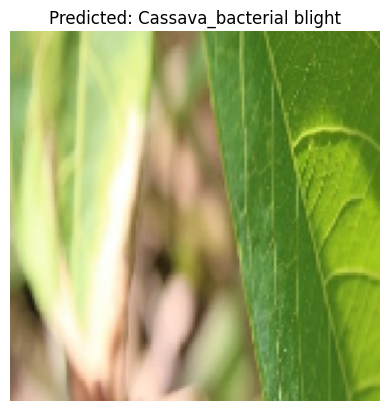

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


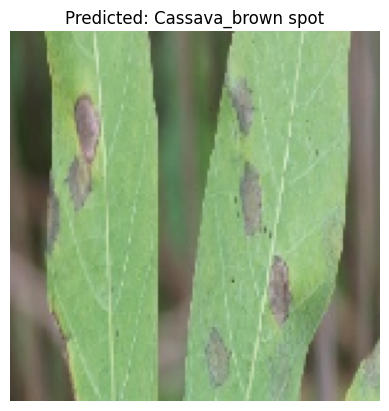

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


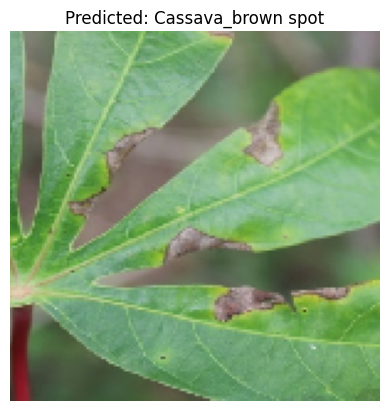

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


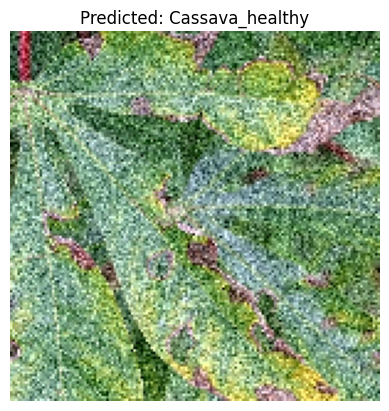

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


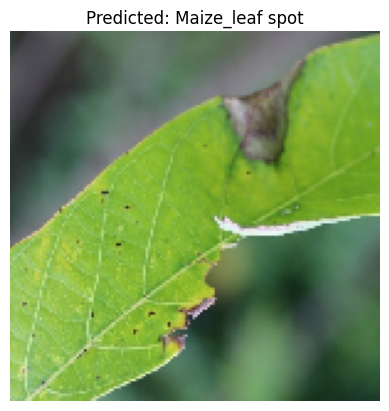

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


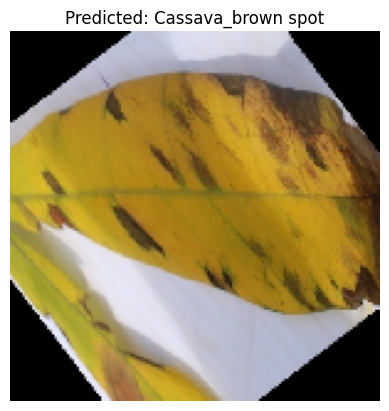

In [ ]:
for folder_name, file_list in images_per_directories.items():
    for file_name in file_list:
        full_image_path = os.path.join(test_image_path, folder_name, file_name)
        predict_image(full_image_path)